In [1]:
import pandas as pd
import os
import matplotlib.pyplot as plt
import numpy as np

data_file_name = os.path.join("results.csv")

df = pd.read_csv(data_file_name)
df["avg_morph_count"] = df["avg_root_count"] + df["avg_prefix_count"] + df["avg_suffix_count"] + df["avg_interfix_count"]
df.columns

Index(['language', 'original_distinct_words', 'original_total_frequency',
       'word_count', 'morph_count', 'word_total_frequency',
       'morph_total_frequency', 'word_ttr', 'morph_ttr', 'word_hapax_count',
       'morph_hapax_count', 'word_hapax_ratio', 'morph_hapax_ratio',
       'word_freq_hapax_count', 'morph_freq_hapax_count',
       'word_freq_hapax_ratio', 'morph_freq_hapax_ratio', 'word_avg_length',
       'morph_avg_length', 'word_avg_length_weighted',
       'morph_avg_length_weighted', 'word_frequency_entropy',
       'morph_frequency_entropy', 'word_frequency_perplexity',
       'morph_frequency_perplexity', 'avg_root_count', 'avg_prefix_count',
       'avg_suffix_count', 'avg_interfix_count', 'avg_root_count_weighted',
       'avg_prefix_count_weighted', 'avg_suffix_count_weighted',
       'avg_interfix_count_weighted', 'cutoff_word_pct', 'avg_morph_count'],
      dtype='object')

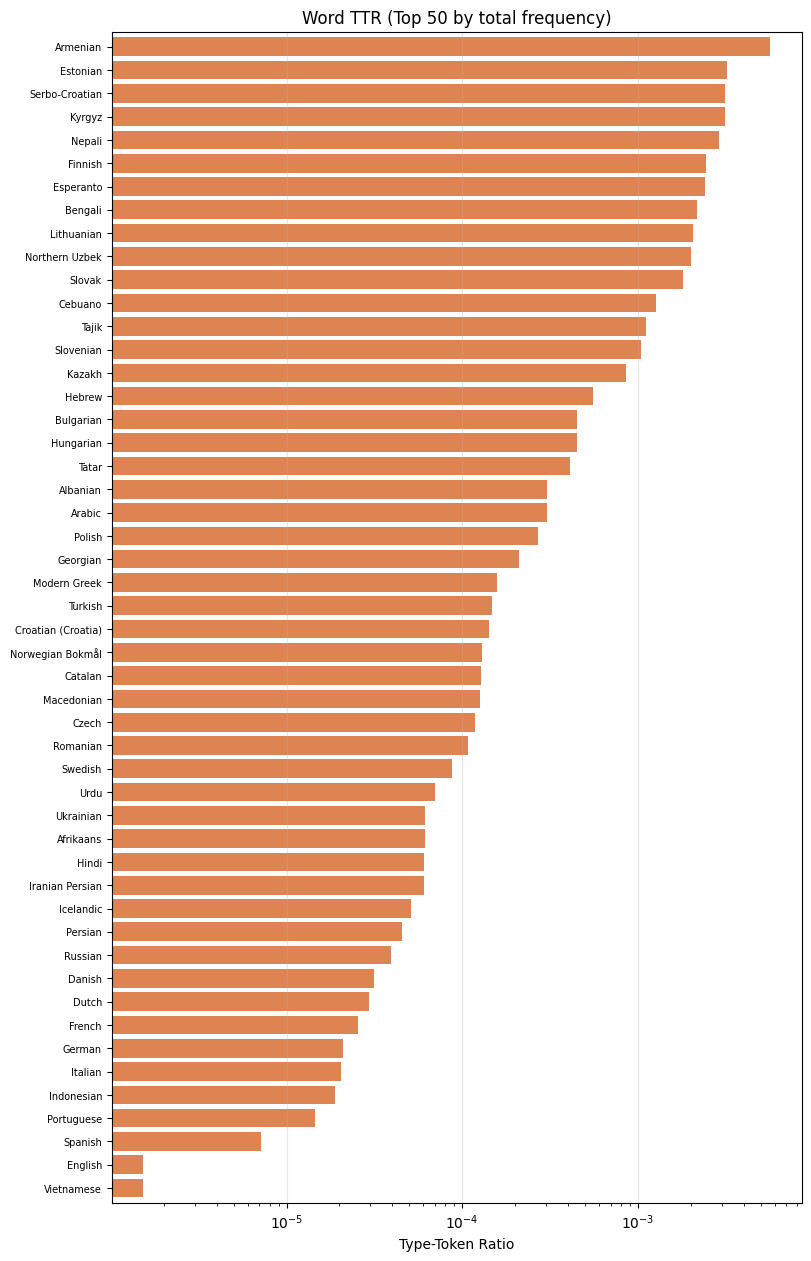

In [2]:
# Word TTR (Top 50 by total frequency, excluding Tamil)
top50 = df[df["language"] != "Tamil"].nlargest(50, "original_total_frequency").sort_values("word_ttr", ascending=True)

fig, ax = plt.subplots(figsize=(8, len(top50) * 0.25))
ax.barh(range(len(top50)), top50["word_ttr"], color="#DD8452")
ax.set_yticks(range(len(top50)))
ax.set_yticklabels(top50["language"], fontsize=7)
ax.set_xlabel("Type-Token Ratio")
ax.set_title("Word TTR (Top 50 by total frequency)")
ax.set_xscale("log")
ax.grid(axis="x", alpha=0.3)
ax.margins(y=0.005)
plt.tight_layout(pad=0.3)
plt.show()

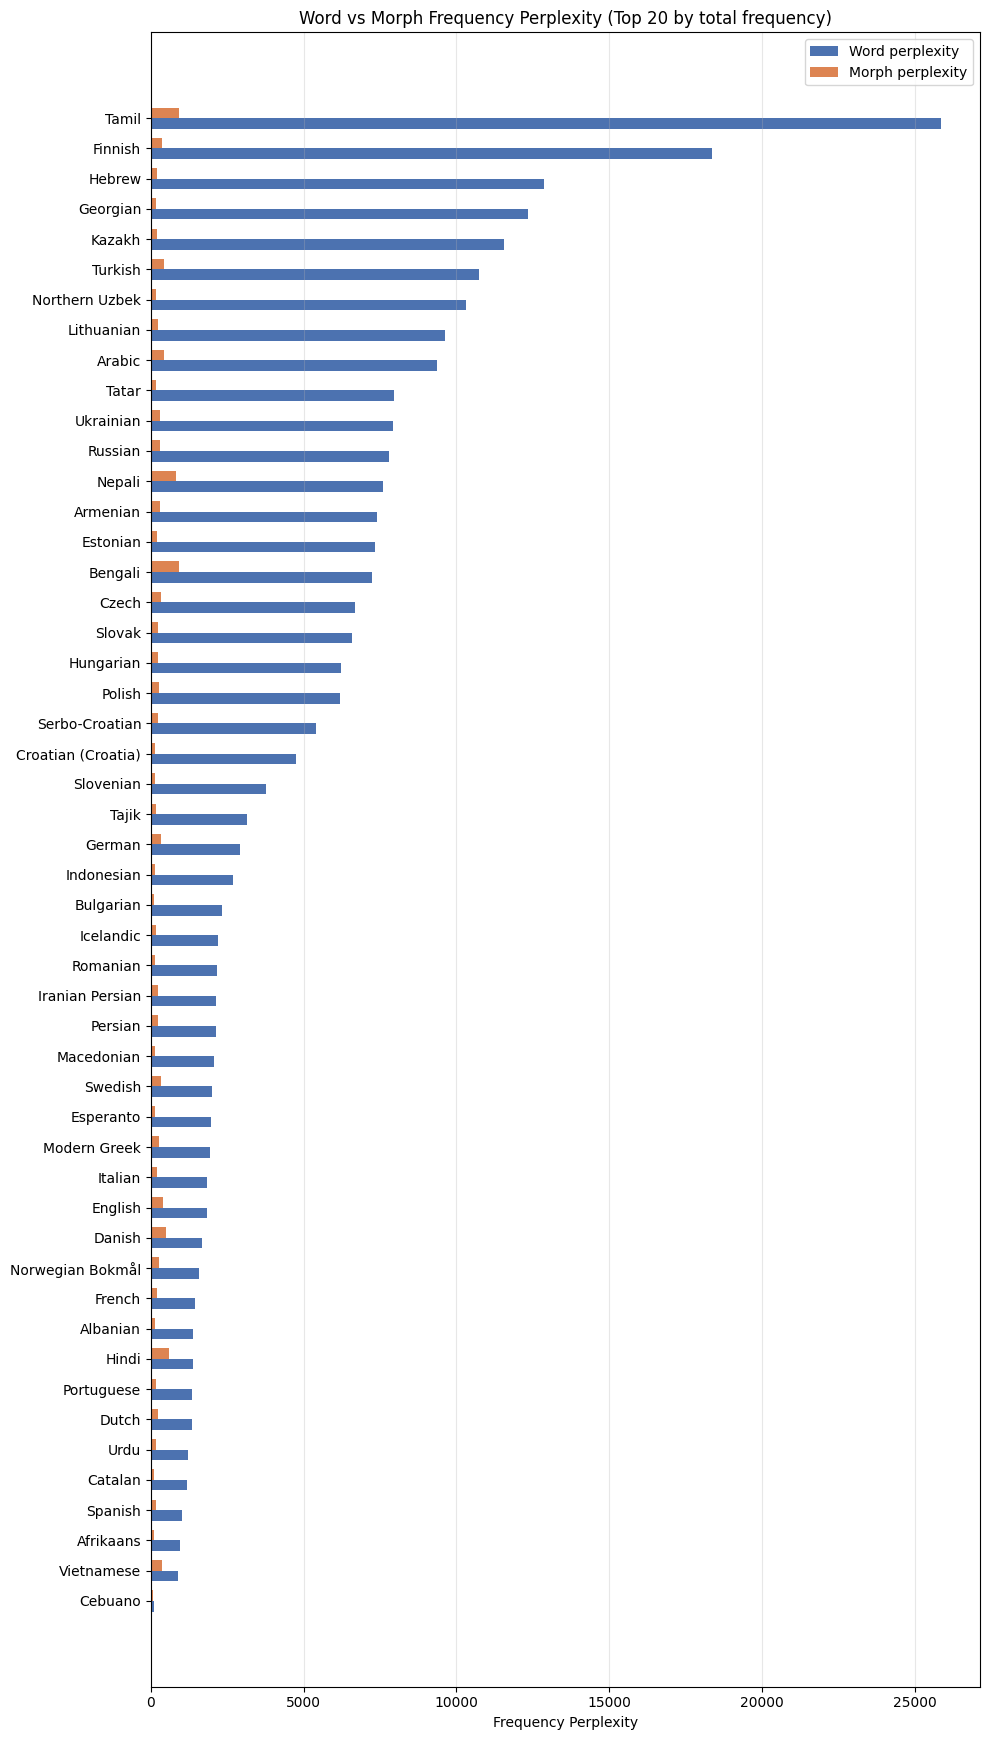

In [3]:
# Top 20 languages by total frequency: word vs morph perplexity
top20 = df.nlargest(50, "original_total_frequency").sort_values("word_frequency_perplexity", ascending=True)

fig, ax = plt.subplots(figsize=(10, max(6, len(top20) * 0.35)))
y = range(len(top20))
height = 0.35

ax.barh([i - height/2 for i in y], top20["word_frequency_perplexity"], height, label="Word perplexity", color="#4C72B0")
ax.barh([i + height/2 for i in y], top20["morph_frequency_perplexity"], height, label="Morph perplexity", color="#DD8452")

ax.set_yticks(list(y))
ax.set_yticklabels(top20["language"])
ax.set_xlabel("Frequency Perplexity")
ax.set_title("Word vs Morph Frequency Perplexity (Top 20 by total frequency)")
ax.legend()
ax.grid(axis="x", alpha=0.3)
plt.tight_layout()
plt.show()

Index(['original_distinct_words', 'original_total_frequency', 'word_count',
       'morph_count', 'word_total_frequency', 'morph_total_frequency',
       'word_ttr', 'morph_ttr', 'word_hapax_count', 'morph_hapax_count',
       'word_hapax_ratio', 'morph_hapax_ratio', 'word_freq_hapax_count',
       'morph_freq_hapax_count', 'word_freq_hapax_ratio',
       'morph_freq_hapax_ratio', 'word_avg_length', 'morph_avg_length',
       'word_avg_length_weighted', 'morph_avg_length_weighted',
       'word_frequency_entropy', 'morph_frequency_entropy',
       'word_frequency_perplexity', 'morph_frequency_perplexity',
       'avg_root_count', 'avg_prefix_count', 'avg_suffix_count',
       'avg_interfix_count', 'avg_root_count_weighted',
       'avg_prefix_count_weighted', 'avg_suffix_count_weighted',
       'avg_interfix_count_weighted', 'cutoff_word_pct', 'avg_morph_count'],
      dtype='object')


C:\Users\Tonda\AppData\Local\Temp\ipykernel_25680\1844992219.py:16: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap("bwr_r").copy()


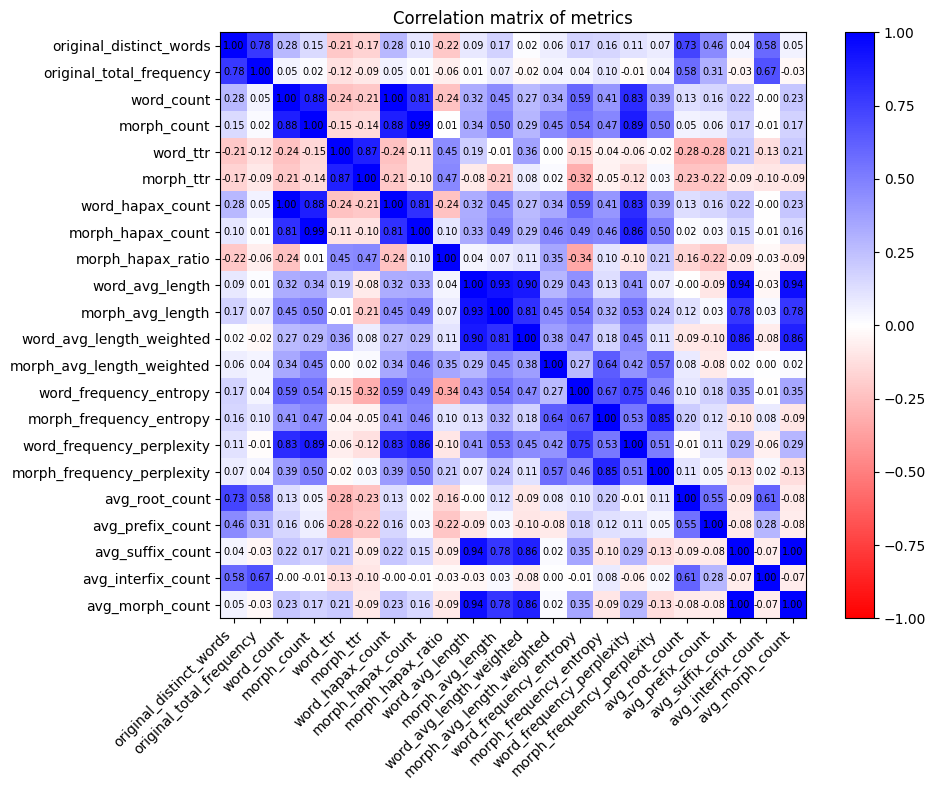

In [4]:
# ── Correlation matrix ──────────────────────────────────────
numeric_cols = df.select_dtypes(include="number").columns

print(numeric_cols)

numeric_cols = numeric_cols.drop(['word_total_frequency', 'morph_total_frequency',
                                  'avg_root_count_weighted', 'avg_prefix_count_weighted', 'avg_suffix_count_weighted',
                                  'avg_interfix_count_weighted', 'cutoff_word_pct',
                                  'word_hapax_ratio', 'word_freq_hapax_count',
                                    'morph_freq_hapax_count', 'word_freq_hapax_ratio',
                                    'morph_freq_hapax_ratio',
                                  ])

corr = df[numeric_cols].corr()

cmap = plt.cm.get_cmap("bwr_r").copy()
cmap.set_bad(color="white")

corr_values = np.ma.masked_invalid(corr.to_numpy())

fig, ax = plt.subplots(figsize=(10, 8))
im = ax.imshow(corr_values, cmap=cmap, vmin=-1, vmax=1)

ax.set_xticks(np.arange(len(corr.columns)))
ax.set_yticks(np.arange(len(corr.index)))
ax.set_xticklabels(corr.columns, rotation=45, ha="right")
ax.set_yticklabels(corr.index)

for i in range(corr.shape[0]):
    for j in range(corr.shape[1]):
        value = corr.iat[i, j]
        ax.text(
            j, i,
            "NaN" if pd.isna(value) else f"{value:.2f}",
            ha="center", va="center", color="black", fontsize=7,
        )

fig.colorbar(im, ax=ax)
plt.title("Correlation matrix of metrics")
plt.tight_layout()
plt.show()

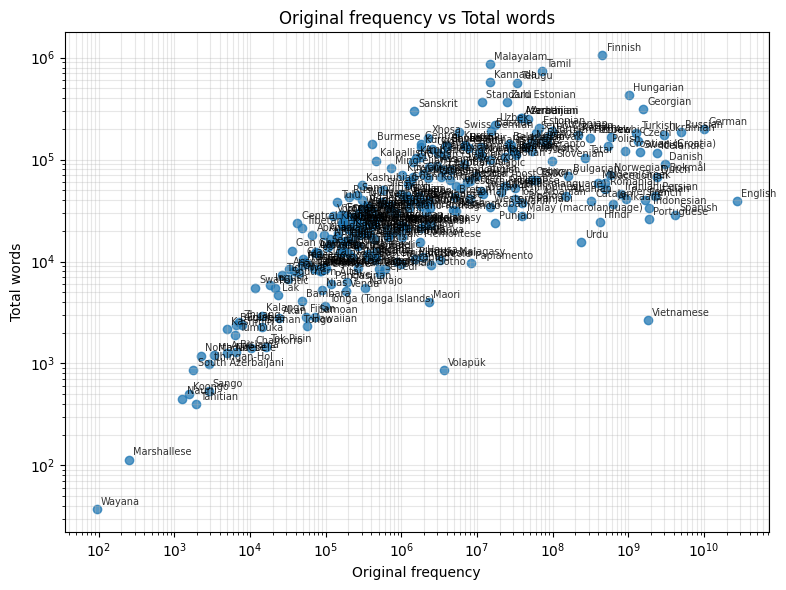

In [5]:
#df = df[~df["language"].str.lower().isin(["english", "finnish"])].copy()

plt.figure(figsize=(8, 6))
plt.scatter(df["original_total_frequency"], df["word_count"], alpha=0.75)
plt.xscale("log")
plt.yscale("log")
plt.xlabel("Original frequency")
plt.ylabel("Total words")
plt.title("Original frequency vs Total words")
plt.grid(True, which="both", axis="both", alpha=0.3)

ax = plt.gca()
for _, row in df.iterrows():
    ax.annotate(
        row["language"],
        (row["original_total_frequency"], row["word_count"]),
        textcoords="offset points",
        xytext=(3, 3),
        fontsize=7,
        alpha=0.8,
    )

plt.tight_layout()
plt.show()

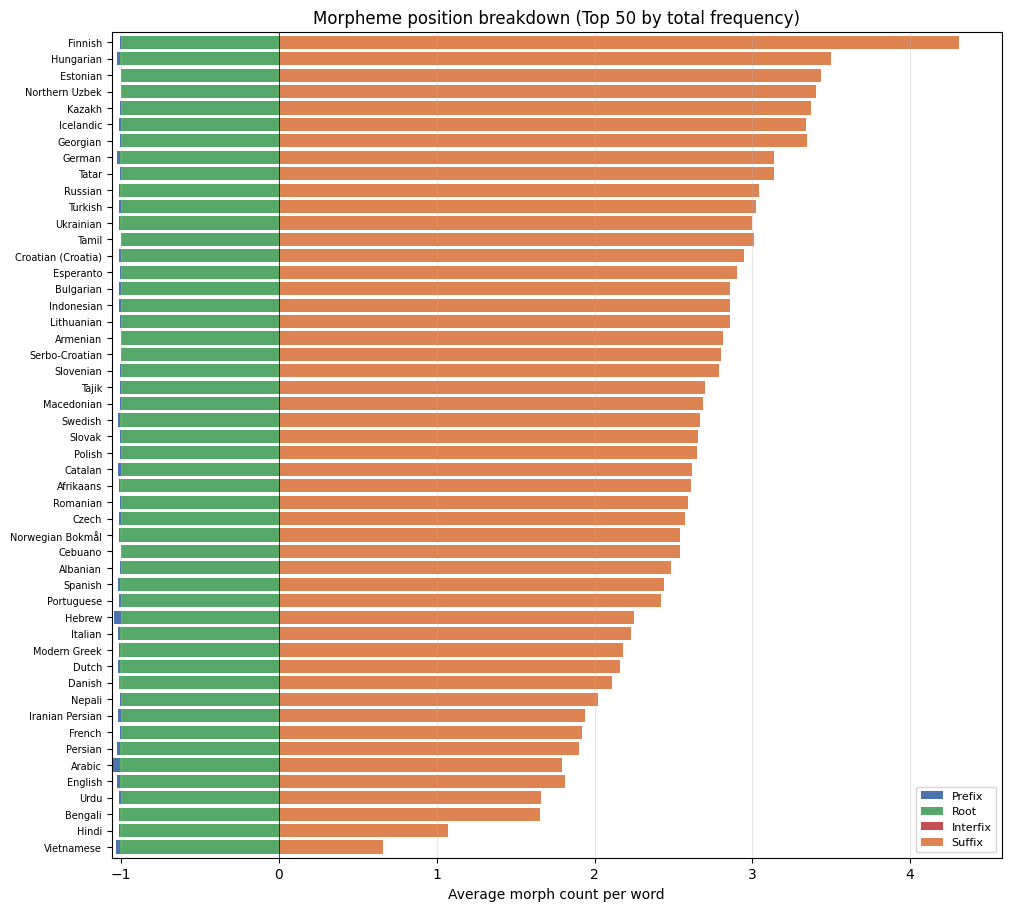

In [6]:
# Morpheme position breakdown (Top 50 by total frequency)
top50m = df.nlargest(50, "original_total_frequency").copy()
top50m["morph_total"] = (top50m["avg_prefix_count"] + top50m["avg_root_count"]
                         + top50m["avg_interfix_count"] + top50m["avg_suffix_count"])
top50m = top50m.sort_values("morph_total", ascending=True)

langs = top50m["language"]
prefixes = top50m["avg_prefix_count"].values
roots = top50m["avg_root_count"].values
interfixes = top50m["avg_interfix_count"].values
suffixes = top50m["avg_suffix_count"].values

fig, ax = plt.subplots(figsize=(10, len(top50m) * 0.18))
y = np.arange(len(top50m))
h = 0.8

# Centered at right edge of root (between root and interfix)
# prefixes + roots extend left from 0, interfixes + suffixes extend right
ax.barh(y, prefixes, height=h, left=-(prefixes + roots), color="#4C72B0", label="Prefix")
ax.barh(y, roots, height=h, left=-roots, color="#55A868", label="Root")
ax.barh(y, interfixes, height=h, left=0, color="#C44E52", label="Interfix")
ax.barh(y, suffixes, height=h, left=interfixes, color="#DD8452", label="Suffix")

ax.set_yticks(y)
ax.set_yticklabels(langs, fontsize=7)
ax.set_xlabel("Average morph count per word")
ax.set_title("Morpheme position breakdown (Top 50 by total frequency)")
ax.axvline(0, color="black", linewidth=0.5)
ax.legend(loc="lower right", fontsize=8)
ax.grid(axis="x", alpha=0.3)
ax.margins(y=0.005)
plt.tight_layout(pad=0.3)
plt.show()

c:\Users\Tonda\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\manifold\_t_sne.py:1164: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(


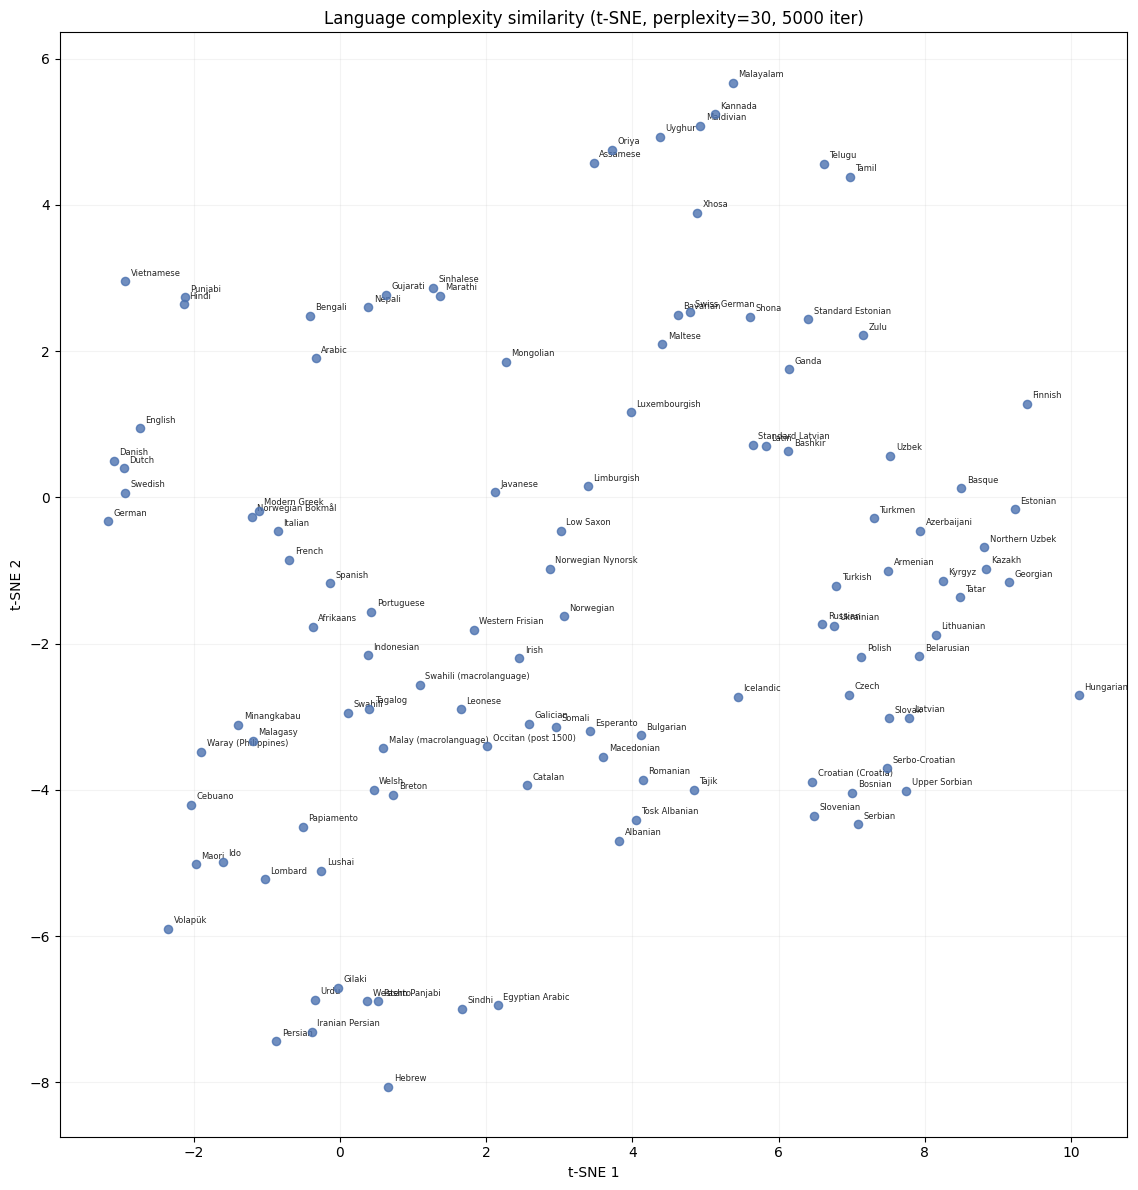

Features: ['word_ttr', 'word_avg_length', 'word_frequency_entropy', 'morph_ttr', 'morph_hapax_ratio', 'morph_avg_length', 'morph_frequency_entropy', 'avg_root_count', 'avg_morph_count']
Languages: 116, KL divergence: 0.3099


In [13]:

# ── Complexity vector: t-SNE 2D projection ──────────────────
from sklearn.preprocessing import StandardScaler
from sklearn.manifold import TSNE

features = [
    "word_ttr", "word_avg_length", "word_frequency_entropy",
    "morph_ttr", "morph_hapax_ratio", "morph_avg_length", "morph_frequency_entropy",
    "avg_root_count", "avg_morph_count",
]

top = df.nlargest(116, "original_total_frequency").copy()
X = top[features].values
scaler = StandardScaler()
X_std = scaler.fit_transform(X)

tsne = TSNE(n_components=2, perplexity=30, random_state=42,
            learning_rate="auto", init="pca", n_iter=5000)
emb = tsne.fit_transform(X_std)

fig, ax = plt.subplots(figsize=(16, 12))
ax.scatter(emb[:, 0], emb[:, 1], s=35, c="#4C72B0", alpha=0.8, zorder=5)

for i, row in enumerate(top.itertuples()):
    ax.annotate(row.language, (emb[i, 0], emb[i, 1]),
                textcoords="offset points", xytext=(4, 4),
                fontsize=6, alpha=0.85)

ax.set_title("Language complexity similarity (t-SNE, perplexity=30, 5000 iter)")
ax.set_xlabel("t-SNE 1")
ax.set_ylabel("t-SNE 2")
ax.grid(True, alpha=0.15)
ax.set_aspect("equal")
plt.tight_layout()
plt.show()

print(f"Features: {features}")
print(f"Languages: {len(top)}, KL divergence: {tsne.kl_divergence_:.4f}")
